In [16]:
import numpy as np
import math
from scipy import constants
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.signal import find_peaks

# defining all the functions

def wavenumber(n, wavelength):
    """
    Outputs the angular wavenumber for propagation of a wave
    Args:
        n (float): index of refraction of the medium
        wavelength (float): the wavelength of the wave in nanometres
    Returns:
        k (float): the wavenumber in per metres
    """
    wavelength = wavelength * (10**-9) # converts to metres
    k = (2 * math.pi * n)/wavelength # calculates k
    return k

def rho(x, y):
    """
    Finds rho for a gaussian beam- being the circular coordinate system
    Args:
        x (float): x coordinate
        y (float): y coordinate
    Returns:
        rho (float): the value of rho at (x,y)
    """
    rho = np.sqrt((x**2)+(y**2))
    return rho

def rayleigh_range(omega_0, wavelength):
    """
    Finds the rayleigh range for a given beam waist radius
    Args:
        omega_0 (float): the waist radius
        wavelength (float): wavelength of the beam in nm
    Returns:
        confocal_parameter (float): the rayleigh range z_0
    """
    wavelength = wavelength * (10**-9) # converts wavelength to metres
    confocal_parameter = (np.pi * (omega_0**2))/wavelength
    return confocal_parameter

def omega_z(omega_0, z, wavelength):
    """
    Calculates omega(z)
    Args:
        omega_0 (float): the waist radius
        z (float): the coordinate in direction of beam propagation
        wavelength (float): wavelength of the beam in nm
    Returns:
        beam_width (float): omega(z) for given args
    """
    square_of_ratio = (z/rayleigh_range(omega_0, wavelength))**2 # finds (z/z_0)^2
    beam_width = omega_0 * np.sqrt(1+square_of_ratio) # w(z) = w_0*(1+(z/z_0)^2)^0.5
    return beam_width

def radius_of_curvature(omega_0, z, wavelength):
    """
    Calculates the radius of curvature of the wavefront
    Args:
        omega_0 (float): the waist radius
        z (float): the coordinate in direction of beam propagation
        wavelength (float): wavelength of the beam in nm
    Returns:
        R_z (float): the radius of curvature of the wavefront at z
    """
    square_of_ratio = (rayleigh_range(omega_0, wavelength)/z)**2 # (z_0/z)^2
    R_z = z * (1 + square_of_ratio)
    return R_z

def zeta_function(omega_0, z, wavelength):
    """
    Performs the relevant zeta function to gaussian beams
    Args:
        omega_0 (float): the waist radius
        z (float): the coordinate in direction of beam propagation
        wavelength (float): wavelength of the beam in nm
    Returns:
        zeta_z (float): the relevant zeta function
    """
    zeta_z = np.atan(z/rayleigh_range(omega_0, wavelength)) # arctan(z/z_0)
    return zeta_z

def gaussian_beam_fresnel(omega_0, z, wavelength, a_0, x, y, n, z1):
    """
    Finds the value for the complex electric field of a given gaussian beam at a given point from creation, multiplied by a scaling factor for use in fresnel diffraction
    Args:
        omega_0 (float): the waist radius
        z (float): the coordinate in direction of beam propagation
        wavelength (float): wavelength of the beam in nm
        a_0 (float): the electric field amplitude at the origin
        x (float): the x coordinate
        y (float): the y coordinate
        n (float): the index of refraction of the medium
        z1 (float): The far distance point
    Returns:
        amplitude (float): the amplitude of the wave
        phase (float): the phase of the wave
    """
    num = complex(0,1)
    scaling_factor = np.e ** ((num * np.pi * (rho(x,y)**2))/((wavelength * 10**-9)*z1))
    amplitude = (a_0 * (omega_0/omega_z(omega_0, z, wavelength)) * (np.e**(-(rho(x, y)**2)/(omega_z(omega_0, z, wavelength))**2)))*scaling_factor
    return amplitude

def calculate_2dft(input):
    """
    Calculates the 2D Fast Fourier Transform of an image/nested array
    Args:
        input (nested np.array): the nested array of values that come out of the gaussian_beam function
    Returns:
        np.fft.ifftshift(ft_1) (nested np.array): the fourier transformed arrays
    """
    ft = np.fft.ifftshift(input) # shifts the input
    ft_1 = np.fft.fft2(ft) # performs 2D fft
    return np.fft.fftshift(ft_1) # inverse shifts

def gaussian_beam(omega_0, z, wavelength, a_0, x, y, n):
    """
    Finds the value for the complex electric field of a given gaussian beam at a given point from creation
    Args:
        omega_0 (float): the waist radius
        z (float): the coordinate in direction of beam propagation
        wavelength (float): wavelength of the beam in nm
        a_0 (float): the electric field amplitude at the origin
        x (float): the x coordinate
        y (float): the y coordinate
        n (float): the index of refraction of the medium
    Returns:
        amplitude (float): the amplitude of the wave
        phase (float): the phase of the wave
    """
    amplitude = a_0 * (omega_0/omega_z(omega_0, z, wavelength)) * (np.e**(-(rho(x, y)**2)/(omega_z(omega_0, z, wavelength))**2))
    return amplitude

def fresnel_diffraction(omega_0, z, wavelength, a_0, x, y, n, z1):
    """
    Performs fresnel diffraction on a beam of given parameters to new position z1
    Args:
        omega_0 (float): the waist radius
        z (float): the coordinate in direction of beam propagation
        wavelength (float): wavelength of the beam in nm
        a_0 (float): the electric field amplitude at the origin
        x (float): the x coordinate
        y (float): the y coordinate
        n (float): the index of refraction of the medium
        z1 (float): The new position of the beam
    NOTE: This function should work with nested arrays due to the use of a 2d fft
    Returns:
        beam (float): the diffracted beam
    """
    # set up complex number i
    num = complex(0,1)

    # calculate and fourier transform initial beam
    near_beam_scaled = gaussian_beam_fresnel(omega_0, z, wavelength, a_0, x, y, n, z1)
    fourier = calculate_2dft(near_beam_scaled)

    # calculate some constants
    k = wavenumber(n, wavelength)
    wavelength = wavelength * 10**-9

    # calculate both the factors before scaling
    factor_1 = (np.e**(num*k*z1))/(num*wavelength*z1)
    factor_2 = np.e ** ((num * np.pi * ((x**2) + (y**2)))/(wavelength*z1))

    # calculate far beam
    beam = factor_1 * factor_2 * fourier
    return beam

def fwhm(x,y):
    """
    Finds the full width at half maximum of the graph
    Args:
        x (np.array): x coord
        y (np.array): y coord
    Returns:
        fw_hm (float): full width at half maximum
    """
    # Target y-value
    target_y = np.max(y)/2
    
    # Find indices where y crosses target_y
    # This detects sign changes in (y - target_y)
    indices = np.where(np.diff(np.sign(y - target_y)) != 0)[0]
    
    # Interpolate to find more accurate x-values
    x_at_target = []
    for i in indices:
        x0, x1 = x[i], x[i+1]
        y0, y1 = y[i], y[i+1]
        # Linear interpolation formula
        x_cross = x0 + (target_y - y0) * (x1 - x0) / (y1 - y0)
        x_at_target.append(x_cross)
    fw_hm = np.sum(abs(np.array(x_at_target)))
    return float(fw_hm)

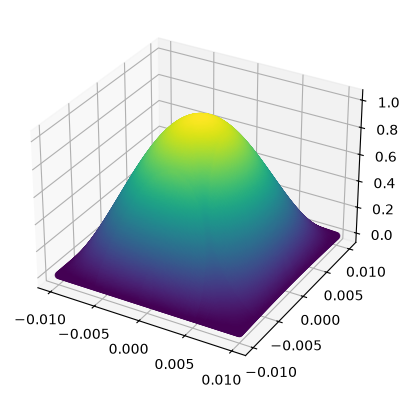

In [21]:
wavelength = 29
omega_0 = 1e-5
z = 1e-10 # at the source
a_0 = 100
n = 1
variable = omega_0 * 1000
z1 = 2

# define initial grid to sample over
grid = np.linspace(-variable, variable, 200)
x, y = np.meshgrid(grid, grid)

# fresnel diffract the beam
beam = fresnel_diffraction(omega_0, z, wavelength, a_0, x, y, n, z1)
beam = abs(beam/np.max(beam)) # normalise

# plot on graph
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x, y, abs(beam), c=beam, marker='o', s=20)
plt.show()

marginal_fft = np.sum(beam,0)
fwhm_1 = fwhm(x, marginal_fft)

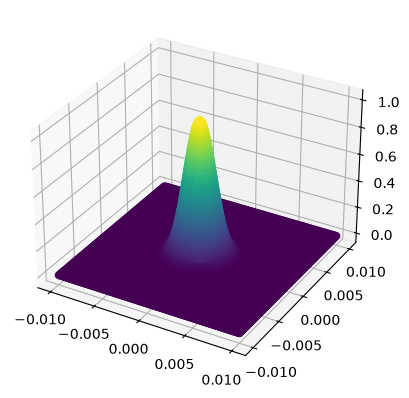

In [22]:
wavelength = 29
omega_0 = 1e-5
z = 1e-10 # at the source
a_0 = 100
n = 1
z1 = 2

# define second beam exactly at distance
amp = gaussian_beam(omega_0, z1, wavelength, a_0, x, y, n)
amp = abs(amp/np.max(amp)) # normalise

# plot on 3d axis
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x, y, abs(amp), c=amp, marker='o', s=20)
plt.show()

marginal = np.sum(amp,0)
fwhm_2 = fwhm(x, marginal)

In [23]:
#find ratios of full width at half maximum to identify if the beams are identical ie successfully diffracted

print(fwhm_2/fwhm_1)

1.0


The fwhm says they are identical, but by observation, they are not